In [1]:
import numpy as np
import scipy as sp
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal,norm
from collections import defaultdict
import warnings
import sklearn.exceptions
from scipy.special import erfinv
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm.notebook import tqdm
import os

import matplotlib.pyplot as plt

from _util import *

warnings.filterwarnings("ignore", category=sklearn.exceptions.ConvergenceWarning)

import rpy2.robjects as robjects
from rpy2.robjects import numpy2ri

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath} \usepackage{amssymb}'
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

np.set_printoptions(edgeitems=30, linewidth=100000, formatter=dict(float=lambda x: "%.3g" % x))


make_plot = lambda n,m,s=[1,1],sharex=False, sharey=False: plt.subplots(n,m,figsize=(m*3*s[0],n*2.5*s[1]),squeeze=False,layout='tight',sharex=sharex, sharey=sharey)
line_style = [
    '-',                  # Solid line.
    '--',                 # Dashed line.
    '-.',                 # Dashdot line.
    ':',                  # Dotted line.
    (0, (3, 5, 1, 5)),    # Custom dash pattern: 3 on, 5 off, 1 on, 5 off.
    (0, (1, 10))         # Custom dash pattern: 1 on, 10 off.
]

def rank_approx(A, k,sort_type="big_small"):
    # Eigenvalue Decomposition (since A is symmetric, we can use eigh)
    eigenvalues, eigenvectors = np.linalg.eigh(A)
    
    # Sort eigenvalues and corresponding eigenvectors in descending order
    if sort_type == "big_small":
        idx = np.argsort(eigenvalues)[::-1]
    elif sort_type == "small_big":
        idx = np.argsort(eigenvalues)
    
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Select the top-k eigenvalues and eigenvectors
    top_eigenvalues = np.diag(eigenvalues[:k])
    top_eigenvectors = eigenvectors[:, :k]
    
    # Reconstruct the rank-k approximation
    A_k = top_eigenvectors @ top_eigenvalues @ top_eigenvectors.T
    
    return A_k


def print_eig(matrix):

    # Validate symmetry
    if not np.allclose(matrix, matrix.T):
      raise ValueError("Error: The matrix is not symmetric.")
    
    # Compute eigenvalues and eigenvectors using an algorithm optimized for symmetric matrices
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    
    # Sort eigenvalues and corresponding eigenvectors in ascending order.
    sorted_indices = np.argsort(eigenvalues)
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]
    
    # Create a DataFrame where each column header is a sorted eigenvalue,
    # and the column entries are the corresponding eigenvector components.
    df = pd.DataFrame(sorted_eigenvectors, columns=[f"{val:.4f}" for val in sorted_eigenvalues])
    
    # Append the final row labeled "sum" with the sum of each column (eigenvector)
    df.loc['sum'] = df.sum(axis=0)
    
    # Configure Pandas display options to avoid wrapping the DataFrame after a set number of columns.
    pd.set_option('display.max_columns', None)
    pd.set_option('display.expand_frame_repr', False)
    
    # Print the table to the console.
    print("Eigenvalue Table:")
    print(df)

def compute_metrics(result, C_true, iC_true, Y):

    if result is None or np.isnan(np.sum(result.iC)):
        result_metrics = {
            'err_C': np.nan,
            'err_iC': np.nan,
            'err_S': np.nan,
            'nnz': np.nan,
            'nll': np.nan,
            'sphr': np.nan,
            'precision': np.nan,
            'recall': np.nan,
            'f1': np.nan,
            'kl': np.nan,
            'aic':np.nan,
            'runtime': np.nan
        }
        return SimpleNamespace(**result_metrics)

    p, n = Y.shape
    S   = np.cov(Y, bias=True)
    C   = result.C + np.eye(p) * 1e-6
    iC  = result.iC + np.eye(p) * 1e-6

    # Use X if available, otherwise default to iC
    X = result.X if hasattr(result, "X") else iC

    # Compute error metrics on covariance/precision matrices
    err_C  = np.linalg.norm(C  - C_true, ord="fro")**2 / np.linalg.norm(C_true, ord="fro")**2
    err_iC = np.linalg.norm(iC - iC_true, ord="fro")**2 / np.linalg.norm(iC_true, ord="fro")**2
    err_S  = np.linalg.norm(C  - S, ord="fro")**2
    nnz    = np.count_nonzero(X) / p
    
    (sign, logdet) = np.linalg.slogdet(iC)
    nll = - (sign * logdet) + np.trace(iC @ S)

    sphr   = p * np.trace(X @ X) / np.trace(X)**2 - 1 
    aic    =  nll + ( nnz  - p )/2 + p

    # Compute KL divergence loss for two zero-mean Gaussians.
    # KL = 0.5 * (trace(iC @ C_true) - p + log(det(C) / det(C_true)))
    kl = 0.5 * (np.trace(iC @ C_true) - p + np.log(np.linalg.det(C) / np.linalg.det(C_true)))
    
    # Compute F1 score for structure recovery of the precision matrix.
    # Threshold the absolute values to define nonzero connections.
    tol = 1e-5
    est_support = np.abs(iC) > tol
    true_support = np.abs(iC_true) > tol

    # Exclude the diagonal entries from evaluation.
    np.fill_diagonal(est_support, False)
    np.fill_diagonal(true_support, False)

    # Flatten binary matrices into 1D arrays.
    y_true = true_support.flatten()
    y_pred = est_support.flatten()

    # Compute the metrics using scikit-learn.
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Compile all computed metrics into a structured object.
    result_metrics = {
        'err_C': err_C,
        'err_iC': err_iC,
        'err_S': err_S,
        'nnz': nnz,
        'nll': nll,
        'sphr': sphr,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'kl': kl,
        'aic':aic,
        'runtime': result.runtime
    }
    return SimpleNamespace(**result_metrics)

def metrics_list(results):
    if len(results)<1:
        return []
    if isinstance(results, list) and results:
        # Dynamically retrieve keys from the first result (e.g., 'err_C', 'err_iC', etc.)
        keys = vars(results[0]).keys()
        aggregated = {key: [getattr(r, key) for r in results] for key in keys}
        return SimpleNamespace(**aggregated)
    else:
        return results

During startup - Warning messages:
1: Setting LC_COLLATE failed, using "C" 
2: Setting LC_TIME failed, using "C" 
3: Setting LC_MESSAGES failed, using "C" 
4: Setting LC_MONETARY failed, using "C" 


# fig1: Tunning Paramter

num nnz = 1128.0
num nnz = 1970.0
num nnz = 2595.0


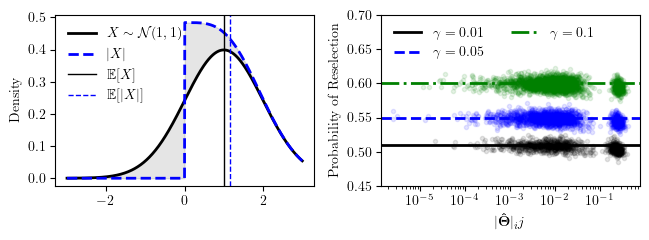

In [ ]:
def cov_analysis(p=128, N=1000,gamma=1/100, data_method='cluster'):

    n = int(p*20)
    k = n/2
    # Generate true covariance
    iC_true, C_true = make_cov(p, data_type=data_method, seed=1)
    Y = make_samples(cov=C_true, n=n,seed=1)
    Y,_,_ = normalize_data(Y)

    res_aquic = compute_aquic(Y,k=k,gamma=gamma) 

    iC = res_aquic.iC
    C  = res_aquic.C

    print("num nnzpr =",np.count_nonzero(iC)/p)

    # Calculate mean and variance of S_k
    S = np.cov(Y, bias=True)
    V = np.outer(np.diag(S), np.diag(S)) + S ** 2

    # Compute  L
    L = erfinv(1 - 2 * gamma) / np.sqrt(2 * k) * np.sqrt(V)
    np.fill_diagonal(L, 0)
    P = np.zeros(shape=(p,p))

    for i in range(N):
        inx_k = np.random.choice(int(n), size=int(k),replace=True)
        Y_k = Y[:, inx_k]
        S_k = np.cov(Y_k, bias=True)
        G_k  = S_k - C
        P = P + (np.abs(G_k) >= L) * 1.0

    P = P / N

    pr_nnz =[]
    pr_z   =[]
    iC_nnz =[]
    iC_z   =[]


    for i in range(p):
        for j in range(i-1):
            if np.abs(iC[i,j]) > 0.0:
                #print(rf"iC[{i},{j}]={iC[i,j]} with prob {P[i,j]}")
                pr_nnz.append(P[i,j])
                iC_nnz.append(iC[i,j])
            else:
                pr_z.append(P[i,j])
                iC_z.append(iC[i,j])

    # pr_nnz = np.sort(pr_nnz)[::-1]
    # pr_z = np.sort(pr_z)[::-1]
    return pr_nnz,pr_z,iC_nnz,iC_z

fig, axs = make_plot(1,2,s=[1.1,1],sharex=False, sharey=False)

inx  = 0
#########################
#########################
mu = 1
sigma = 1
x = np.linspace(-4, 4, 1000)

pdf_normal = sp.stats.norm.pdf(x, mu, sigma)
c = abs(mu / sigma)

pdf_folded  = sp.stats.foldnorm.pdf(x, c, scale=sigma)
mean_folded = sp.stats.foldnorm.mean(c, scale=sigma)

# Normal distribution
axs[0,inx].plot(x, pdf_normal, label=r"$X\sim\mathcal{N}(1,1)$", color="black",linestyle="-",linewidth=2)
axs[0,inx].fill_between(x[x < 0], pdf_normal[x < 0], color='black', alpha=0.1)

# Folded normal distribution
axs[0,inx].plot(x, pdf_folded, label=r"$|X|$", color="blue",linestyle="--",linewidth=2)

# Highlighting how negative side maps to positive side in folded normal
axs[0,inx].fill_between(x[x>0],pdf_folded[x > 0], pdf_normal[x > 0], color='black', alpha=0.1)

# Mean lines
axs[0,inx].axvline(mu, color='black', label=r"$\mathbb{E}[X]$",linestyle="-",linewidth=1)
axs[0,inx].axvline(mean_folded, color='blue', label=r"$\mathbb{E}[|X|]$",linestyle="--",linewidth=1)

axs[0, inx].set_ylabel(r'Density')

axs[0, inx].legend(loc='upper left',frameon=False,fontsize=10)

inx = inx + 1
#########################
#########################
ax = axs[0, inx]
data_method = "cluster"
# … after plotting your markers …

for color, linestyle, gamma in [
    ('black', '-', 0.01),
    ('blue',  '--', 0.05),
    ('green','-.', 0.10)
]:
    # 1) re‑run your semilogx for clarity (or omit if already plotted)
    pr_nnz, pr_z, iC_nnz, iC_z = cov_analysis(
        p=128, gamma=gamma, data_method=data_method, N=10000
    )
    ax.semilogx(
        np.abs(iC_nnz),
        pr_nnz,
        linestyle='None',
        marker='.',
        color=color,
        alpha=0.1,
        label="_"
    )
    ax.axhline(y=(0.5 + gamma), color=color, linewidth=2, linestyle=linestyle, alpha=1, label=rf'$\gamma={gamma}$')

axs[0, inx].set_ylabel(r'Probability of Reselection')
axs[0, inx].set_xlabel(r'$|\mathbf{\hat{\Theta}}_{ij}|$')

axs[0, inx].set_ylim([0.45,0.7])
axs[0, inx].legend(loc='upper left',frameon=False,fontsize=10,ncol=2)

#axs[0, inx].plot(np.abs(iC_z),pr_z, linestyle='None',marker='*', color='black',label=rf'$\gamma={gamma}\;$')

# axs[0, inx].plot(T,         color='black',linewidth=2, linestyle='-',label=rf'$\gamma={gamma}\;$')
# axs[0, inx].axhline(y=(0.5 + gamma), color='black', linestyle='-',alpha=.5)
# axs[0, inx].axvline(x=len(T),        color='black', linestyle='-',alpha=.5)

# gamma= 0.1
# T = cov_analysis(gamma=gamma, data_method=data_method)
# axs[0, inx].plot(T,         color='blue',linewidth=2, linestyle='--',label=rf'$\gamma={gamma}\;$')
# axs[0, inx].axhline(y=(0.5 + gamma), color='blue', linestyle='--',alpha=.5)
# axs[0, inx].axvline(x=len(T),        color='blue', linestyle='--',alpha=.5)

# gamma= 0.4
# T = cov_analysis(gamma=gamma,  data_method=data_method)
# axs[0, inx].plot(T, color='red',linewidth=2, linestyle='-.',label=rf'$\gamma={gamma}\;$')
# axs[0, inx].axhline(y=(0.5 + gamma), color='red', linestyle='-.',alpha=.5)
# axs[0, inx].axvline(x=len(T), color='red', linestyle='-.',alpha=.5)

# axs[0, inx].set_xlabel(r'Index Count')

#axs[0, 0].legend(loc='center',frameon=False)
#axs[0, 0].set_ylabel(r'Measured Prob. of Reselection')

# axs[0, 1].set_xlabel(r'Index Count ($\;(i,j) \in \mathcal{I}_{\tiny{\text{u}}}\;$)')
#axs[0, 2].set_xlabel(r'Nonzero Indices ($(i,j) \in \mathcal{I}_{\tiny{\text{free}}}$)')

# fig.savefig("fig_1.png", dpi=300, bbox_inches='tight')

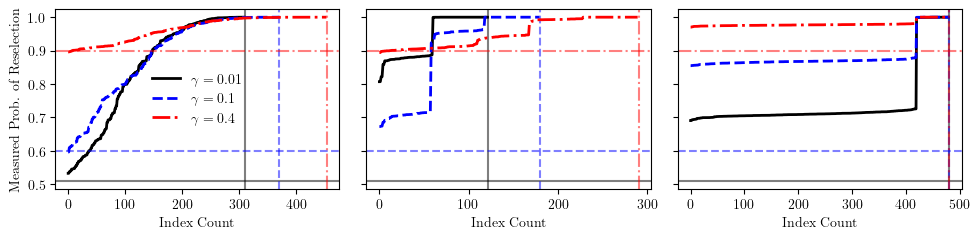

In [2]:
def cov_analysis(p=32, num=5000, gamma=0.01, k=50, data_method='cluster', seed=3):

    # Generate true covariance
    iC_true, C_true = make_cov(p, data_type=data_method, seed=seed)

    C = np.eye(p)

    # Initialize lists to store sample covariance and deviations from C
    S_k = []
    G_k = []

    # Generate samples and compute covariances
    for i in range(num):
        Y_k      = make_samples(cov=C_true, n=k,seed=i)
        Y_k, _,_ = normalize_data(Y_k)
        S_k.append(np.cov(Y_k, bias=True))
        G_k.append(S_k[-1] - C)

    # Convert lists to arrays
    S_k = np.array(S_k)
    G_k = np.array(G_k)

    # Calculate mean and variance of S_k
    S = np.mean(S_k, axis=0)
    G = np.mean(G_k, axis=0)
    V = np.outer(np.diag(S), np.diag(S)) + S ** 2

    # Compute confidence threshold L
    L = erfinv(1 - 2 * gamma) / np.sqrt(2 * k) * np.sqrt(V)

    # Compute mean of indicator matrices
    P_mean = np.zeros((p, p))
    for G_ki in G_k:
        P_mean = P_mean + (np.abs(G_ki) > L).astype(int)
    P_mean = P_mean/num

    # Compute final selection matrix and filter values
    P_select = (np.abs(G) > L).astype(int)
    T = (P_mean * P_select).flatten()
    T = T[T != 0]
    return T

fig, axs = make_plot(1,3,s=[1.1,1],sharex=False, sharey=True)

inx  = 0
k           = 128
data_method = 'cluster'
gamma= 0.01
T = cov_analysis(gamma=gamma, k=k, data_method=data_method)
axs[0, inx].plot(np.sort(T),         color='black',linewidth=2, linestyle='-',label=rf'$\gamma={gamma}\;$')
axs[0, inx].axhline(y=(0.5 + gamma), color='black', linestyle='-',alpha=.5)
axs[0, inx].axvline(x=len(T),        color='black', linestyle='-',alpha=.5)

gamma= 0.1
T = cov_analysis(gamma=gamma, k=k, data_method=data_method)
axs[0, inx].plot(np.sort(T),         color='blue',linewidth=2, linestyle='--',label=rf'$\gamma={gamma}\;$')
axs[0, inx].axhline(y=(0.5 + gamma), color='blue', linestyle='--',alpha=.5)
axs[0, inx].axvline(x=len(T),        color='blue', linestyle='--',alpha=.5)

gamma= 0.4
T = cov_analysis(gamma=gamma, k=k, data_method=data_method)
axs[0, inx].plot(np.sort(T),         color='red',linewidth=2, linestyle='-.',label=rf'$\gamma={gamma}\;$')
axs[0, inx].axhline(y=(0.5 + gamma), color='red', linestyle='-.',alpha=.5)
axs[0, inx].axvline(x=len(T),        color='red', linestyle='-.',alpha=.5)
axs[0, inx].set_xlabel(r'Index Count')


inx = inx + 1

data_method = 'band'
gamma= 0.01
T = cov_analysis(gamma=gamma, k=k, data_method=data_method)
axs[0, inx].plot(np.sort(T),         color='black',linewidth=2, linestyle='-',label=rf'$\gamma={gamma}\;$')
axs[0, inx].axhline(y=(0.5 + gamma), color='black', linestyle='-',alpha=.5)
axs[0, inx].axvline(x=len(T),        color='black', linestyle='-',alpha=.5)

gamma= 0.1
T = cov_analysis(gamma=gamma, k=k, data_method=data_method)
axs[0, inx].plot(np.sort(T),         color='blue',linewidth=2, linestyle='--',label=rf'$\gamma={gamma}\;$')
axs[0, inx].axhline(y=(0.5 + gamma), color='blue', linestyle='--',alpha=.5)
axs[0, inx].axvline(x=len(T),        color='blue', linestyle='--',alpha=.5)

gamma= 0.4
T = cov_analysis(gamma=gamma, k=k, data_method=data_method)
axs[0, inx].plot(np.sort(T),         color='red',linewidth=2, linestyle='-.',label=rf'$\gamma={gamma}\;$')
axs[0, inx].axhline(y=(0.5 + gamma), color='red', linestyle='-.',alpha=.5)
axs[0, inx].axvline(x=len(T),        color='red', linestyle='-.',alpha=.5)

axs[0, inx].set_xlabel(r'Index Count')


inx = inx + 1

data_method = 'hub'
gamma= 0.01
T = cov_analysis(gamma=gamma, k=k, data_method=data_method)
axs[0, inx].plot(np.sort(T),         color='black',linewidth=2, linestyle='-',label=rf'$\gamma={gamma}\;$')
axs[0, inx].axhline(y=(0.5 + gamma), color='black', linestyle='-',alpha=.5)
axs[0, inx].axvline(x=len(T),        color='black', linestyle='-',alpha=.5)

gamma= 0.1
T = cov_analysis(gamma=gamma, k=k, data_method=data_method)
axs[0, inx].plot(np.sort(T),         color='blue',linewidth=2, linestyle='--',label=rf'$\gamma={gamma}\;$')
axs[0, inx].axhline(y=(0.5 + gamma), color='blue', linestyle='--',alpha=.5)
axs[0, inx].axvline(x=len(T),        color='blue', linestyle='--',alpha=.5)

gamma= 0.4
T = cov_analysis(gamma=gamma, k=k, data_method=data_method)
axs[0, inx].plot(np.sort(T),         color='red',linewidth=2, linestyle='-.',label=rf'$\gamma={gamma}\;$')
axs[0, inx].axhline(y=(0.5 + gamma), color='red', linestyle='-.',alpha=.5)
axs[0, inx].axvline(x=len(T),        color='red', linestyle='-.',alpha=.5)

axs[0, inx].set_xlabel(r'Index Count')

axs[0, 0].legend(loc='center',frameon=False)
axs[0, 0].set_ylabel(r'Measured Prob. of Reselection')

# axs[0, 1].set_xlabel(r'Index Count ($\;(i,j) \in \mathcal{I}_{\tiny{\text{u}}}\;$)')
#axs[0, 2].set_xlabel(r'Nonzero Indices ($(i,j) \in \mathcal{I}_{\tiny{\text{free}}}$)')

fig.savefig("fig_1.png", dpi=300, bbox_inches='tight')

# fig2: Sampling Distribution NNZ

32
64
128
256
512
1024


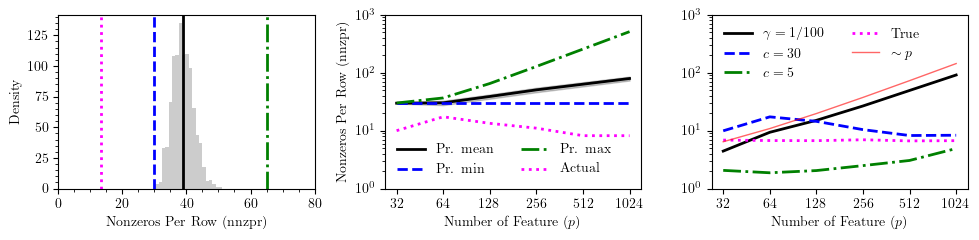

In [8]:
def single_run1(p,n,c,data_type):

    iC_true, C_true = make_cov(p, data_type=data_type, seed=0, dense=True)
    Y = make_samples(cov=C_true, n=int(n), seed=2)
    Y,_,_ = normalize_data(Y)
    S = np.cov(Y,bias=True)

    k = n / 2 
    r = 0.5 * p * (1.0 - sp.special.erf(2.0 * sp.special.erfinv(1.0 - c / p)))
    gamma = r / p    

    diagS = np.diagonal(S)                         
    V = S**2 + np.outer(diagS, diagS)              
    L = np.sqrt(V) * sp.special.erfinv(1.0 - 2.0 * gamma) / np.sqrt(2.0 * k)
    np.fill_diagonal(L, 1e-12)

    res_aquic = compute_aquic(Y,c=c,k=k)

    C  = res_aquic.W
    iC = res_aquic.X

    nnzpr_min = p*(1- sp.special.erf(0.5 *  sp.special.erfinv(1-2*gamma)))
    nnzpr_max = p*(1/2+gamma)
    nnzpr_actual =(np.count_nonzero(iC))/p
    nnzpr_true =(np.count_nonzero(iC_true))/p

    N = 1000
    nnzpr_set = np.zeros(N)

    for i in range(N):
        inx_k = np.random.choice(int(n), size=int(k))
        Y_k = Y[:, inx_k]
        S_k = np.cov(Y_k, bias=True)
        G_k  = S_k - C
        P = (np.abs(G_k) >= L) * 1.0
        nnzpr = (np.count_nonzero(P))/p
        nnzpr_set[i] = nnzpr
    
    return nnzpr_set,nnzpr_min,nnzpr_max,nnzpr_actual,nnzpr_true

def single_run2(p_line, data_type):

    nnz1 = np.zeros(len(p_line))
    nnz2 = np.zeros(len(p_line))
    nnz3 = np.zeros(len(p_line))
    nnz_true = np.zeros(len(p_line))
    for inx,p in enumerate(p_line):
        print(p)

        n = p/2
        iC_true, C_true = make_cov(p, data_type=data_type, seed=0)
        Y = make_samples(cov=C_true, n=int(n), seed=1)
        nnz_true[inx] = np.count_nonzero(iC_true) / p

        res_aquic1 = compute_aquic(Y,gamma=1/100)
        met_aquic1 = compute_metrics(res_aquic1, C_true, iC_true, Y)

        res_aquic2 = compute_aquic(Y,c=30)
        met_aquic2 = compute_metrics(res_aquic2, C_true, iC_true, Y)

        res_aquic3 = compute_aquic(Y,c=5)
        met_aquic3 = compute_metrics(res_aquic3, C_true, iC_true, Y)

        nnz1[inx]=met_aquic1.nnz
        nnz2[inx]=met_aquic2.nnz
        nnz3[inx]=met_aquic3.nnz

    return nnz1,nnz2,nnz3,nnz_true

data_type = "cluster"

fig, axs = make_plot(1,3,s=[1.1,1],sharex=False, sharey=False)

p = 128
n = p/2
c = 30

########################################
########################################
inx = 0
nnzpr_set,nnzpr_min,nnzpr_max,nnzpr_actual,nnzpr_true = single_run1(p,n,c,data_type)
axs[0,inx].hist(nnzpr_set,bins=20,density=False,color="black",alpha=.2)
axs[0,inx].axvline(x=np.mean(nnzpr_set),color="black",    linestyle="-",  linewidth=2, label=f"Prob. mean")
axs[0,inx].axvline(x=nnzpr_min,         color="blue",     linestyle="--", linewidth=2,label=f"Prob. min")
axs[0,inx].axvline(x=nnzpr_max,         color="green",    linestyle="-.", linewidth=2,label=f"Prob. max")
axs[0,inx].axvline(x=nnzpr_actual,      color="magenta",  linestyle=":",  linewidth=2,label=f"Actual")
axs[0,inx].minorticks_on()
axs[0,inx].set_xlim([0,80])
axs[0,inx].set_ylabel(f"Density")
axs[0,inx].set_xlabel(f"Nonzeros Per Row (nnzpr)")


########################################
########################################
c = 30
p_line = [32,64,128,256,512,1024]

nnzpr_set_mean   = np.zeros(len(p_line))
nnzpr_set_std    = np.zeros(len(p_line))
nnzpr_min_set    = np.zeros(len(p_line))
nnzpr_max_set    = np.zeros(len(p_line))
nnzpr_actual_set = np.zeros(len(p_line))

for i, p in enumerate(p_line):
    n = p/2
    nnzpr_set,nnzpr_min,nnzpr_max,nnzpr_actual,nnzpr_true = single_run1(p,n,c,data_type)
    nnzpr_set_mean[i]   = np.mean(nnzpr_set)
    nnzpr_set_std[i]    = np.std(nnzpr_set)
    nnzpr_min_set[i]    = nnzpr_min
    nnzpr_max_set[i]    = nnzpr_max
    nnzpr_actual_set[i] = nnzpr_actual

inx = 1
axs[0,inx].loglog(p_line,nnzpr_set_mean,color="black",     linewidth=2 ,linestyle="-",label=f"Pr. mean")
axs[0,inx].fill_between(p_line, nnzpr_set_mean + nnzpr_set_std, nnzpr_set_mean - nnzpr_set_std, alpha=.2, color="black")
axs[0,inx].loglog(p_line,nnzpr_min_set,color="blue",       linewidth=2 ,linestyle="--",label=f"Pr. min")
axs[0,inx].loglog(p_line,nnzpr_max_set,color="green",      linewidth=2 ,linestyle="-.",label=f"Pr. max")
axs[0,inx].loglog(p_line,nnzpr_actual_set,color="magenta", linewidth=2 ,linestyle=":",label=f"Actual")
axs[0,inx].set_xticks(p_line)
axs[0,inx].set_xscale('log', base=2)
axs[0,inx].minorticks_on()
axs[0,inx].set_xticks(p_line)
axs[0,inx].set_ylim([1,1e3])
axs[0,inx].set_xticklabels([str(int(val)) for val in p_line])
axs[0,inx].set_ylabel(f"Nonzeros Per Row (nnzpr)")
axs[0,inx].set_xlabel(f"Number of Feature ($p$)")
axs[0, inx].legend(loc='lower left', frameon=False, fontsize=10, ncol=2)

########################################
########################################
p_line = [32,64,128,256,512,1024]

inx = 2
nnz1,nnz2,nnz3,nnz_true = single_run2(p_line, data_type)
axs[0,inx].loglog(p_line,nnz1,color="black",linestyle="-",       linewidth=2 , label=f"$\gamma=1/100$")
axs[0,inx].loglog(p_line,nnz2,color="blue", linestyle="--",      linewidth=2 , label=f"$c=30$")
axs[0,inx].loglog(p_line,nnz3,color="green", linestyle="-.",     linewidth=2 , label=f"$c=5$")
axs[0,inx].loglog(p_line,nnz_true,color="magenta",linestyle=":", linewidth=2 , label=f"True")

base = nnz1[0]
y = np.array(p_line)
y = (base / y[0]) * y + 2

axs[0,inx].loglog(p_line,y,color="red",linestyle="-", linewidth=1 ,label=f"$\sim p$", alpha=.6)

axs[0,inx].set_xscale('log', base=2)
axs[0,inx].set_xticks(p_line)
axs[0,inx].set_xticklabels([str(int(val)) for val in p_line])
axs[0,inx].set_ylim([1,1e3])

axs[0,inx].set_xlabel(f"Number of Feature ($p$)")
axs[0,inx].legend(loc="upper left", frameon=False, fontsize=10, ncol=2)

fig.savefig("fig_2.png", dpi=300, bbox_inches='tight')

# fig3: Err 1 - Fixed $p$, change in $n$

In [4]:
def single_run(inx, n_ratio, C_true, iC_true):
    
    p = C_true.shape[0]
    n = int( np.ceil(n_ratio * p))
    Y = make_samples(cov=C_true, n=int(n), seed=inx)
    
    res_glasso = None
    res_tiger  = None
    res_clime  = None
    res_aquic1 = None
    res_aquic2 = None

    # GLASSO
    res_glasso = compute_glasso(Y)
    met_glasso = compute_metrics(res_glasso, C_true, iC_true, Y)

    #TIGER 
    res_tiger = compute_tiger(Y)
    met_tiger = compute_metrics(res_tiger, C_true, iC_true, Y)

    # CLIME  
    res_clime = compute_clime(Y)
    met_clime = compute_metrics(res_clime, C_true, iC_true, Y)

    # AQUIC 
    res_aquic1 = compute_aquic(Y,c=30,k=n/2)
    met_aquic1 = compute_metrics(res_aquic1, C_true, iC_true, Y)

    # AQUIC 
    res_aquic2 = compute_aquic(Y,c=5,k=n/2)
    met_aquic2 = compute_metrics(res_aquic2, C_true, iC_true, Y)

    print(
        f"- nnzpr {np.count_nonzero(iC_true)/p:.1f} | "
        f"glasso {met_glasso.runtime:.3f}s ({met_glasso.nnz:.1f}, f1={met_glasso.f1:.3f}) | "
        f"tiger {met_tiger.runtime:.3f}s ({met_tiger.nnz:.1f}, f1={met_tiger.f1:.3f}) | "
        f"clime {met_clime.runtime:.3f}s ({met_clime.nnz:.1f}, f1={met_clime.f1:.3f}) | "
        f"aquic1 {met_aquic1.runtime:.3f}s ({met_aquic1.nnz:.1f}, f1={met_aquic1.f1:.3f}) | "
        f"aquic2 {met_aquic2.runtime:.3f}s ({met_aquic2.nnz:.1f}, f1={met_aquic2.f1:.3f}) | "        
    )

    return {
        'glasso':  met_glasso,
        'tiger':   met_tiger,
        'clime':   met_clime,
        'aquic1':  met_aquic1,
        'aquic2':  met_aquic2,
    }


def convert_to_dataframes(raw_data):
    out = {}
    # Use the methods in the first task result as reference.
    for method in raw_data[0]:
        # Get the metric names from the first non-None result.
        first_valid = next((ns for ns in raw_data[0][method] if ns is not None), None)
        if first_valid is None:
            continue
        metric_names = list(first_valid.__dict__.keys())
        method_metrics = {}
        # For each metric, build one column per task.
        for metric in metric_names:
            # Each column corresponds to one task (one n_ratio value)
            cols = [
                np.array([ns.__dict__[metric] if ns is not None else np.nan for ns in task[method]])
                for task in raw_data
            ]
            # Stack columns horizontally so that rows are iterations.
            matrix = np.column_stack(cols)
            method_metrics[metric] = pd.DataFrame(matrix, columns=list(range(len(raw_data))))
        out[method] = SimpleNamespace(**method_metrics)
    return out

p  = 128
N  = 10

os.environ["PYTHONWARNINGS"] = "ignore"  # Applies to all subprocesses

data_type_list = ["cluster", "band", "hub"]

dataframes = {}
for data_type in data_type_list:
    print("Processing data type:", data_type)
    
    # Generate covariance matrix and samples.
    iC_true, C_true = make_cov(p, data_type=data_type, seed=0)

    # Define the n_ratio values.
    n_ratio_set = np.logspace(np.log2(1./8.), np.log2(2.0), num=10,base=2)
    
    # For each n_ratio value, run 100 iterations in parallel.
    raw_data = []  # Will be a list (length = number of n_ratio values).
    for n_ratio in n_ratio_set:
        print(f"Running n_ratio={n_ratio} iterations")
        
        task_input_list = [(inx, n_ratio, C_true, iC_true) for inx in range(N)]
        single_results = []
        for args in tqdm(task_input_list, total=N, desc=f"n_ratio={n_ratio} iterations"):
            result = single_run(*args)
            single_results.append(result)
        
        # For each method, we now want a list of 100 results.
        task_result = {method: [res[method] for res in single_results]
                       for method in single_results[0]}
        raw_data.append(task_result)
    
    # Convert the raw_data (list per n_ratio value) into matrices per metric.
    dataframes[data_type] = convert_to_dataframes(raw_data)

file_name = 'data_err1.pkl'
pd.to_pickle([n_ratio_set,dataframes], file_name)    

Processing data type: cluster
Running n_ratio=0.125 iterations


n_ratio=0.125 iterations:   0%|          | 0/10 [00:00<?, ?it/s]

- nnzpr 6.7 | glasso 4.876s (7.7, f1=0.151) | tiger 0.877s (1.0, f1=0.000) | clime 6.326s (1.3, f1=0.000) | aquic1 0.047s (10.0, f1=0.159) | aquic2 0.025s (1.0, f1=0.000) | 
- nnzpr 6.7 | glasso 2.748s (9.6, f1=0.155) | tiger 0.759s (1.0, f1=0.000) | clime 5.600s (1.2, f1=0.005) | aquic1 0.022s (9.9, f1=0.162) | aquic2 0.004s (1.0, f1=0.000) | 
- nnzpr 6.7 | glasso 2.168s (4.1, f1=0.117) | tiger 0.795s (1.0, f1=0.000) | clime 6.196s (1.2, f1=0.000) | aquic1 0.004s (9.9, f1=0.159) | aquic2 0.004s (1.0, f1=0.000) | 
- nnzpr 6.7 | glasso 2.328s (10.5, f1=0.172) | tiger 0.798s (1.0, f1=0.000) | clime 5.918s (1.3, f1=0.000) | aquic1 0.030s (10.2, f1=0.172) | aquic2 0.008s (1.0, f1=0.000) | 
- nnzpr 6.7 | glasso 5.348s (7.1, f1=0.098) | tiger 0.816s (1.3, f1=0.010) | clime 5.659s (1.2, f1=0.000) | aquic1 0.031s (9.7, f1=0.112) | aquic2 0.023s (1.0, f1=0.000) | 
- nnzpr 6.7 | glasso 1.682s (1.6, f1=0.025) | tiger 0.749s (1.0, f1=0.000) | clime 6.253s (1.4, f1=0.000) | aquic1 0.036s (9.0, f1=0

n_ratio=0.17009875002179714 iterations:   0%|          | 0/10 [00:00<?, ?it/s]

- nnzpr 6.7 | glasso 2.221s (4.9, f1=0.169) | tiger 0.912s (1.0, f1=0.000) | clime 5.852s (1.4, f1=0.005) | aquic1 0.042s (11.0, f1=0.197) | aquic2 0.024s (1.0, f1=0.000) | 
- nnzpr 6.7 | glasso 1.347s (3.4, f1=0.154) | tiger 0.799s (1.0, f1=0.000) | clime 7.340s (1.5, f1=0.005) | aquic1 0.022s (10.8, f1=0.190) | aquic2 0.021s (1.0, f1=0.000) | 
- nnzpr 6.7 | glasso 2.174s (5.9, f1=0.177) | tiger 0.933s (1.6, f1=0.069) | clime 6.797s (1.4, f1=0.010) | aquic1 0.034s (10.8, f1=0.188) | aquic2 0.022s (1.0, f1=0.000) | 
- nnzpr 6.7 | glasso 2.083s (8.6, f1=0.183) | tiger 0.904s (1.7, f1=0.083) | clime 6.634s (1.5, f1=0.025) | aquic1 0.035s (11.0, f1=0.185) | aquic2 0.024s (1.0, f1=0.005) | 
- nnzpr 6.7 | glasso 2.007s (4.9, f1=0.111) | tiger 0.837s (1.0, f1=0.000) | clime 6.278s (1.3, f1=0.000) | aquic1 0.031s (10.6, f1=0.143) | aquic2 0.046s (1.0, f1=0.000) | 
- nnzpr 6.7 | glasso 2.313s (1.8, f1=0.082) | tiger 0.782s (1.0, f1=0.000) | clime 7.467s (1.5, f1=0.000) | aquic1 0.023s (10.3, f

...

- nnzpr 2.9 | glasso 1.992s (11.2, f1=0.312) | tiger 5.556s (3.4, f1=0.739) | clime 17.211s (3.7, f1=0.362) | aquic1 0.069s (14.4, f1=0.247) | aquic2 0.022s (3.4, f1=0.780) | 
- nnzpr 2.9 | glasso 2.010s (9.3, f1=0.366) | tiger 6.208s (3.3, f1=0.738) | clime 15.473s (3.5, f1=0.415) | aquic1 0.063s (14.5, f1=0.243) | aquic2 0.039s (3.8, f1=0.752) | 
- nnzpr 2.9 | glasso 2.106s (10.9, f1=0.314) | tiger 5.878s (3.5, f1=0.764) | clime 17.539s (3.8, f1=0.356) | aquic1 0.078s (14.6, f1=0.242) | aquic2 0.051s (3.5, f1=0.756) | 
- nnzpr 2.9 | glasso 1.861s (9.5, f1=0.360) | tiger 5.758s (3.5, f1=0.759) | clime 14.288s (2.9, f1=0.343) | aquic1 0.067s (15.4, f1=0.230) | aquic2 0.038s (3.5, f1=0.775) | 
- nnzpr 2.9 | glasso 2.184s (10.7, f1=0.321) | tiger 5.933s (3.4, f1=0.742) | clime 17.623s (3.8, f1=0.482) | aquic1 0.037s (14.4, f1=0.243) | aquic2 0.028s (3.7, f1=0.744) | 
- nnzpr 2.9 | glasso 2.317s (12.4, f1=0.282) | tiger 5.736s (3.3, f1=0.763) | clime 18.559s (3.9, f1=0.425) | aquic1 0.060

n_ratio=1.4697344922755986 iterations:   0%|          | 0/10 [00:00<?, ?it/s]

- nnzpr 2.9 | glasso 2.418s (10.0, f1=0.348) | tiger 7.532s (3.8, f1=0.772) | clime 11.932s (3.1, f1=0.459) | aquic1 0.079s (14.5, f1=0.246) | aquic2 0.049s (3.9, f1=0.783) | 
- nnzpr 2.9 | glasso 2.051s (12.4, f1=0.286) | tiger 8.434s (3.7, f1=0.778) | clime 13.450s (3.6, f1=0.505) | aquic1 0.048s (14.9, f1=0.240) | aquic2 0.026s (4.1, f1=0.744) | 
- nnzpr 2.9 | glasso 2.134s (10.9, f1=0.322) | tiger 7.643s (3.5, f1=0.799) | clime 12.334s (2.9, f1=0.465) | aquic1 0.072s (14.6, f1=0.244) | aquic2 0.038s (3.9, f1=0.757) | 
- nnzpr 2.9 | glasso 2.265s (12.4, f1=0.285) | tiger 7.735s (3.6, f1=0.803) | clime 13.184s (3.3, f1=0.483) | aquic1 0.063s (15.8, f1=0.227) | aquic2 0.036s (3.9, f1=0.793) | 
- nnzpr 2.9 | glasso 2.539s (9.6, f1=0.360) | tiger 7.433s (3.3, f1=0.830) | clime 11.841s (2.8, f1=0.487) | aquic1 0.125s (14.7, f1=0.242) | aquic2 0.021s (3.9, f1=0.763) | 
- nnzpr 2.9 | glasso 2.585s (10.3, f1=0.335) | tiger 8.253s (3.7, f1=0.792) | clime 10.640s (2.7, f1=0.428) | aquic1 0.05

n_ratio=2.0 iterations:   0%|          | 0/10 [00:00<?, ?it/s]

- nnzpr 2.9 | glasso 3.085s (12.2, f1=0.288) | tiger 12.136s (3.6, f1=0.824) | clime 11.493s (2.7, f1=0.563) | aquic1 0.064s (15.3, f1=0.234) | aquic2 0.057s (4.2, f1=0.740) | 
- nnzpr 2.9 | glasso 2.134s (11.7, f1=0.300) | tiger 13.280s (3.7, f1=0.800) | clime 11.382s (3.0, f1=0.545) | aquic1 0.066s (15.0, f1=0.237) | aquic2 0.054s (4.5, f1=0.706) | 
- nnzpr 2.9 | glasso 2.567s (10.4, f1=0.334) | tiger 11.601s (3.8, f1=0.807) | clime 13.434s (3.3, f1=0.642) | aquic1 0.059s (14.8, f1=0.241) | aquic2 0.108s (4.1, f1=0.752) | 
- nnzpr 2.9 | glasso 1.825s (10.9, f1=0.321) | tiger 11.904s (3.7, f1=0.825) | clime 13.255s (3.4, f1=0.603) | aquic1 0.115s (15.5, f1=0.230) | aquic2 0.061s (4.1, f1=0.761) | 
- nnzpr 2.9 | glasso 2.301s (10.1, f1=0.343) | tiger 11.723s (3.7, f1=0.801) | clime 10.130s (2.7, f1=0.520) | aquic1 0.068s (14.6, f1=0.243) | aquic2 0.055s (4.1, f1=0.754) | 
- nnzpr 2.9 | glasso 2.972s (12.1, f1=0.292) | tiger 12.668s (3.7, f1=0.824) | clime 10.107s (2.6, f1=0.595) | aqui

Figure size (width x height in pixels): [9 12.2] 1.3611111111111112


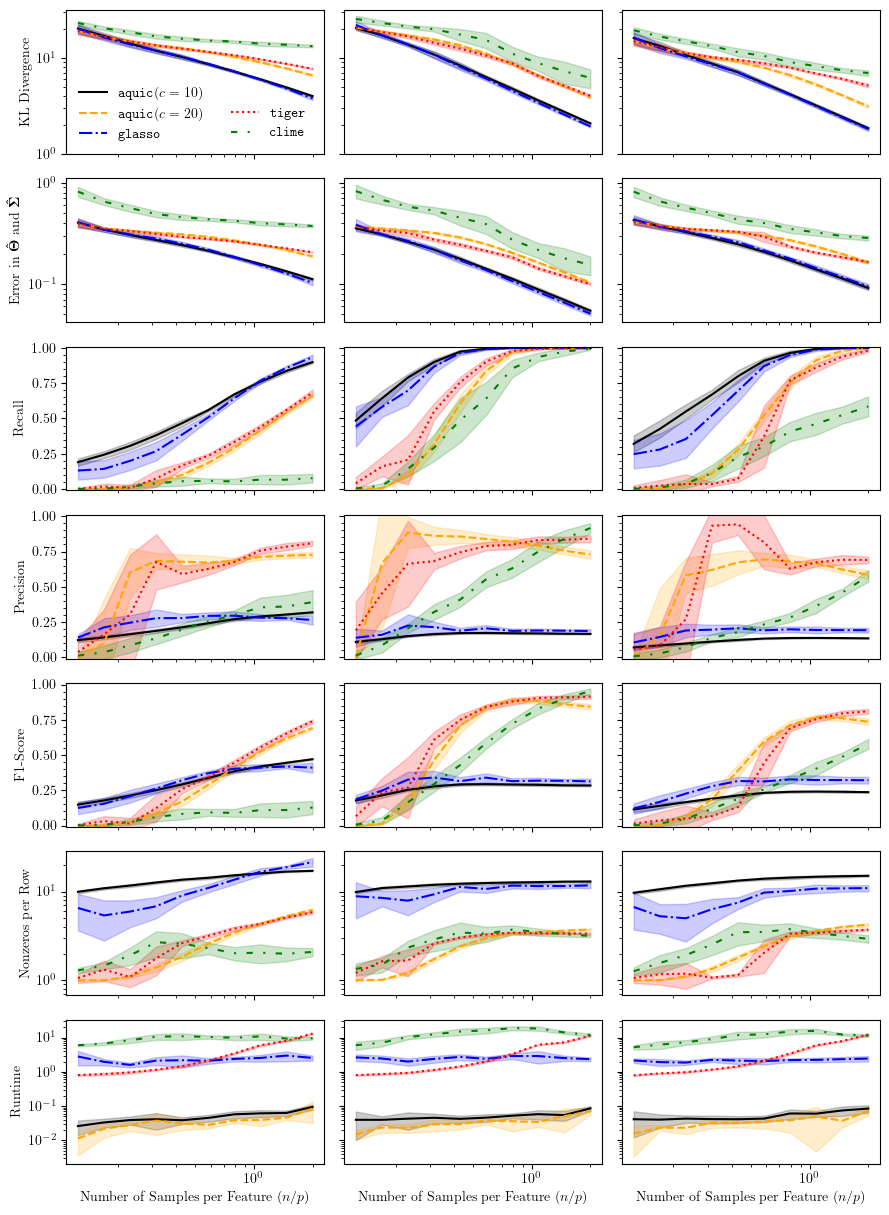

In [5]:
file_name = "data_err1"
[x_line, dataframe] = pd.read_pickle(file_name + ".pkl") 

fig, axs = make_plot(7, 3, s=[1, .7], sharex=True, sharey='row')

std_band = 1

i = 0
# KL Divergence
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    
    # aquic1
    m = dataframe[data_type]['aquic1'].kl.mean(0)
    v = dataframe[data_type]['aquic1'].kl.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}(c=10)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    #aquic2
    m = dataframe[data_type]['aquic2'].kl.mean(0)
    v = dataframe[data_type]['aquic2'].kl.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}(c=20)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].kl.mean(0)
    v = dataframe[data_type]['glasso'].kl.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    axs[i, inx].loglog([], [],linestyle=None,label=r" ",linewidth=0)

    # tiger
    m = dataframe[data_type]['tiger'].kl.mean(0)
    v = dataframe[data_type]['tiger'].kl.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].kl.mean(0)
    v = dataframe[data_type]['clime'].kl.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([1, None])
axs[i, 0].set_ylabel(r'KL Divergence')
axs[i, 0].minorticks_on()

i = i + 1
# Error in C and iC
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = (dataframe[data_type]['aquic1'].err_iC.mean(0) + dataframe[data_type]['aquic1'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['aquic1'].err_iC.std(0) + dataframe[data_type]['aquic1'].err_C.std(0)) / 2) * std_band
    axs[i, inx].loglog(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}(c=10)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = (dataframe[data_type]['aquic2'].err_iC.mean(0) + dataframe[data_type]['aquic2'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['aquic2'].err_iC.std(0) + dataframe[data_type]['aquic2'].err_C.std(0)) / 2) * std_band
    axs[i, inx].loglog(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}(c=20)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = (dataframe[data_type]['glasso'].err_iC.mean(0) + dataframe[data_type]['glasso'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['glasso'].err_iC.std(0) + dataframe[data_type]['glasso'].err_C.std(0)) / 2) * std_band
    axs[i, inx].loglog(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = (dataframe[data_type]['tiger'].err_iC.mean(0) + dataframe[data_type]['tiger'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['tiger'].err_iC.std(0) + dataframe[data_type]['tiger'].err_C.std(0)) / 2) * std_band  
    axs[i, inx].loglog(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = (dataframe[data_type]['clime'].err_iC.mean(0) + dataframe[data_type]['clime'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['clime'].err_iC.std(0) + dataframe[data_type]['clime'].err_C.std(0)) / 2) * std_band
    axs[i, inx].loglog(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylabel(r"Error in $\mathbf{\hat{\Theta}}$ and $\mathbf{\hat{\Sigma}}$")
axs[i, 0].minorticks_on()

i = i + 1
# Recall
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].recall.mean(0)
    v = dataframe[data_type]['aquic1'].recall.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}(c=10)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].recall.mean(0)
    v = dataframe[data_type]['aquic2'].recall.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}(c=20)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].recall.mean(0)
    v = dataframe[data_type]['glasso'].recall.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].recall.mean(0)
    v = dataframe[data_type]['tiger'].recall.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].recall.mean(0)
    v = dataframe[data_type]['clime'].recall.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'Recall')
axs[i, 0].minorticks_on()

i = i + 1
# Precision
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].precision.mean(0)
    v = dataframe[data_type]['aquic1'].precision.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}(c=10)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].precision.mean(0)
    v = dataframe[data_type]['aquic2'].precision.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}(c=20)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].precision.mean(0)
    v = dataframe[data_type]['glasso'].precision.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].precision.mean(0)
    v = dataframe[data_type]['tiger'].precision.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].precision.mean(0)
    v = dataframe[data_type]['clime'].precision.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'Precision')
axs[i, 0].minorticks_on()

i = i + 1
# F1 Score
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].f1.mean(0)
    v = dataframe[data_type]['aquic1'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}(c=10)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].f1.mean(0)
    v = dataframe[data_type]['aquic2'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}(c=20)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].f1.mean(0)
    v = dataframe[data_type]['glasso'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].f1.mean(0)
    v = dataframe[data_type]['tiger'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].f1.mean(0)
    v = dataframe[data_type]['clime'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'F1-Score')
axs[i, 0].minorticks_on()

i = i + 1
# Nonzeros per Row
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].nnz.mean(0)
    v = dataframe[data_type]['aquic1'].nnz.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}(c=10)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].nnz.mean(0)
    v = dataframe[data_type]['aquic2'].nnz.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}(c=20)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].nnz.mean(0)
    v = dataframe[data_type]['glasso'].nnz.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].nnz.mean(0)
    v = dataframe[data_type]['tiger'].nnz.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].nnz.mean(0)
    v = dataframe[data_type]['clime'].nnz.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylabel(r'Nonzeros per Row')
axs[i, 0].minorticks_on()

i = i + 1
# Runtime
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].runtime.mean(0)
    v = dataframe[data_type]['aquic1'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}(c=10)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].runtime.mean(0)
    v = dataframe[data_type]['aquic2'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}(c=20)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].runtime.mean(0)
    v = dataframe[data_type]['glasso'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].runtime.mean(0)
    v = dataframe[data_type]['tiger'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].runtime.mean(0)
    v = dataframe[data_type]['clime'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")
    
    #axs[i, inx].set_xticks([.1,.5,1,1.5, 2])
    axs[i, inx].set_xlabel(r'Number of Samples per Feature ($n/p$)')

axs[i, 0].set_ylabel(r'Runtime')
axs[i, 0].minorticks_on()

axs[0, 0].legend(loc='lower left', frameon=False, fontsize=10, ncol=2)

fig.savefig("fig_3.png", dpi=300, bbox_inches='tight')

fig_size_pixels = fig.get_size_inches()
print("Figure size (width x height in pixels):", fig_size_pixels, fig_size_pixels[1] / fig_size_pixels[0])

# fig4: Err 2 - Fixed $n$, change in $p$

In [6]:
def single_run(inx, n, C_true, iC_true):
    
    p = C_true.shape[0]
    Y = make_samples(cov=C_true, n=int(n), seed=inx)
    
    res_glasso = None
    res_tiger  = None
    res_clime  = None
    res_aquic1 = None
    res_aquic2 = None

    # GLASSO
    res_glasso = compute_glasso(Y)
    met_glasso = compute_metrics(res_glasso, C_true, iC_true, Y)

    #TIGER 
    if p < 1024:
        res_tiger = compute_tiger(Y)
    met_tiger = compute_metrics(res_tiger, C_true, iC_true, Y)

    # CLIME  
    if p < 512:
        res_clime = compute_clime(Y)
    met_clime = compute_metrics(res_clime, C_true, iC_true, Y)

    # AQUIC 
    res_aquic1 = compute_aquic(Y,c=30,k=n/2)
    met_aquic1 = compute_metrics(res_aquic1, C_true, iC_true, Y)

    # AQUIC 
    res_aquic2 = compute_aquic(Y,c=5,k=n/2)
    met_aquic2 = compute_metrics(res_aquic2, C_true, iC_true, Y)

    print(
        f"- nnzpr {np.count_nonzero(iC_true)/p:.1f} | "
        f"glasso {met_glasso.runtime:.3f}s ({met_glasso.nnz:.1f}, f1={met_glasso.f1:.3f}) | "
        f"tiger {met_tiger.runtime:.3f}s ({met_tiger.nnz:.1f}, f1={met_tiger.f1:.3f}) | "
        f"clime {met_clime.runtime:.3f}s ({met_clime.nnz:.1f}, f1={met_clime.f1:.3f}) | "
        f"aquic1 {met_aquic1.runtime:.3f}s ({met_aquic1.nnz:.1f}, f1={met_aquic1.f1:.3f}) | "
        f"aquic2 {met_aquic2.runtime:.3f}s ({met_aquic2.nnz:.1f}, f1={met_aquic2.f1:.3f}) | "        
    )

    return {
        'glasso': met_glasso,
        'tiger': met_tiger,
        'clime': met_clime,
        'aquic1': met_aquic1,
        'aquic2': met_aquic2,
    }

def convert_to_dataframes(raw_data):
    out = {}
    # Use the methods in the first task result as reference.
    for method in raw_data[0]:
        # Get the metric names from the first non-None result.
        first_valid = next((ns for ns in raw_data[0][method] if ns is not None), None)
        if first_valid is None:
            continue
        metric_names = list(first_valid.__dict__.keys())
        method_metrics = {}
        # For each metric, build one column per task.
        for metric in metric_names:
            # Each column corresponds to one task (one n_ratio value)
            cols = [
                np.array([ns.__dict__[metric] if ns is not None else np.nan for ns in task[method]])
                for task in raw_data
            ]
            # Stack columns horizontally so that rows are iterations.
            matrix = np.column_stack(cols)
            method_metrics[metric] = pd.DataFrame(matrix, columns=list(range(len(raw_data))))
        out[method] = SimpleNamespace(**method_metrics)
    return out

r = 2
N = 10

os.environ["PYTHONWARNINGS"] = "ignore" 

#data_type_list = ["cluster", "band", "random", "hub", "sf"]
data_type_list = ["cluster", "band", "hub"]

dataframes = {}
for data_type in data_type_list:
    print("\n Processing data type:", data_type)
    
    # Define the n_ratio values.
    p_set = [32,64,128,256,512,1024]

    # For each n_ratio value, run 100 iterations in parallel.
    raw_data = []  # Will be a list (length = number of n_ratio values).
    for p in p_set:
        # Generate covariance matrix and samples.
        iC_true, C_true = make_cov(p, data_type=data_type, seed=0)
        n = p/r
        task_input_list = [(inx, n, C_true, iC_true) for inx in range(N)]
        single_results = []
        for args in tqdm(task_input_list, total=N, desc=f"p={p} iterations"):
            result = single_run(*args)
            single_results.append(result)
        
        # For each method, we now want a list of 100 results.
        task_result = {method: [res[method] for res in single_results]
                       for method in single_results[0]}
        raw_data.append(task_result)
    
    # Convert the raw_data (list per n_ratio value) into matrices per metric.
    dataframes[data_type] = convert_to_dataframes(raw_data)

file_name = "data_err2"
pd.to_pickle([p_set,dataframes], file_name + '.pkl')    


 Processing data type: cluster


p=32 iterations:   0%|          | 0/10 [00:00<?, ?it/s]

- nnzpr 6.9 | glasso 0.247s (2.8, f1=0.213) | tiger 0.393s (1.8, f1=0.075) | clime 0.450s (1.4, f1=0.000) | aquic1 0.000s (9.9, f1=0.380) | aquic2 0.000s (2.0, f1=0.109) | 
- nnzpr 6.9 | glasso 0.142s (5.9, f1=0.326) | tiger 0.379s (1.1, f1=0.021) | clime 0.514s (1.7, f1=0.000) | aquic1 0.001s (9.9, f1=0.371) | aquic2 0.000s (2.1, f1=0.108) | 
- nnzpr 6.9 | glasso 0.145s (9.3, f1=0.432) | tiger 0.398s (1.0, f1=0.000) | clime 0.492s (2.0, f1=0.000) | aquic1 0.001s (9.9, f1=0.430) | aquic2 0.000s (2.5, f1=0.186) | 
- nnzpr 6.9 | glasso 0.138s (6.8, f1=0.366) | tiger 0.382s (1.8, f1=0.112) | clime 0.476s (1.3, f1=0.000) | aquic1 0.000s (9.8, f1=0.368) | aquic2 0.000s (2.4, f1=0.190) | 
- nnzpr 6.9 | glasso 0.189s (2.9, f1=0.240) | tiger 0.377s (1.1, f1=0.042) | clime 0.466s (1.4, f1=0.000) | aquic1 0.001s (9.7, f1=0.361) | aquic2 0.000s (2.4, f1=0.207) | 
- nnzpr 6.9 | glasso 0.166s (8.2, f1=0.333) | tiger 0.411s (1.0, f1=0.000) | clime 0.474s (1.4, f1=0.000) | aquic1 0.001s (9.2, f1=0.34

p=64 iterations:   0%|          | 0/10 [00:00<?, ?it/s]

- nnzpr 6.8 | glasso 0.339s (7.8, f1=0.340) | tiger 0.542s (2.1, f1=0.174) | clime 1.392s (1.9, f1=0.037) | aquic1 0.008s (16.8, f1=0.296) | aquic2 0.001s (1.8, f1=0.152) | 
- nnzpr 6.8 | glasso 0.362s (12.0, f1=0.310) | tiger 0.543s (1.0, f1=0.000) | clime 1.656s (2.5, f1=0.060) | aquic1 0.004s (17.3, f1=0.289) | aquic2 0.004s (1.9, f1=0.170) | 
- nnzpr 6.8 | glasso 0.389s (10.5, f1=0.324) | tiger 0.519s (2.4, f1=0.228) | clime 1.133s (1.4, f1=0.000) | aquic1 0.007s (17.3, f1=0.295) | aquic2 0.002s (2.2, f1=0.214) | 
- nnzpr 6.8 | glasso 0.394s (10.5, f1=0.348) | tiger 0.558s (1.0, f1=0.011) | clime 1.413s (1.9, f1=0.009) | aquic1 0.006s (16.9, f1=0.335) | aquic2 0.002s (1.8, f1=0.154) | 
- nnzpr 6.8 | glasso 0.330s (8.4, f1=0.318) | tiger 0.580s (1.1, f1=0.021) | clime 1.209s (1.6, f1=0.010) | aquic1 0.006s (16.3, f1=0.300) | aquic2 0.004s (2.3, f1=0.178) | 
- nnzpr 6.8 | glasso 0.366s (4.5, f1=0.339) | tiger 0.497s (1.0, f1=0.000) | clime 1.372s (1.5, f1=0.000) | aquic1 0.005s (17.2

...

- nnzpr 2.9 | glasso 4.354s (11.3, f1=0.299) | tiger 16.846s (3.6, f1=0.743) | clime 110.908s (3.8, f1=0.480) | aquic1 0.207s (10.3, f1=0.326) | aquic2 0.058s (2.9, f1=0.772) | 
- nnzpr 2.9 | glasso 4.817s (9.1, f1=0.365) | tiger 15.097s (3.5, f1=0.731) | clime 111.242s (3.6, f1=0.435) | aquic1 0.177s (9.9, f1=0.340) | aquic2 0.081s (2.7, f1=0.747) | 
- nnzpr 2.9 | glasso 3.098s (10.9, f1=0.320) | tiger 15.614s (3.6, f1=0.726) | clime 121.890s (4.2, f1=0.426) | aquic1 0.167s (10.4, f1=0.330) | aquic2 0.106s (2.8, f1=0.781) | 
- nnzpr 2.9 | glasso 4.087s (11.4, f1=0.291) | tiger 16.203s (3.6, f1=0.715) | clime 99.970s (3.5, f1=0.415) | aquic1 0.111s (10.6, f1=0.311) | aquic2 0.053s (2.8, f1=0.763) | 
- nnzpr 2.9 | glasso 3.813s (10.6, f1=0.324) | tiger 15.601s (3.5, f1=0.776) | clime 107.360s (3.8, f1=0.517) | aquic1 0.137s (10.5, f1=0.326) | aquic2 0.059s (2.8, f1=0.818) | 
- nnzpr 2.9 | glasso 4.690s (10.7, f1=0.315) | tiger 16.779s (3.5, f1=0.718) | clime 124.684s (4.6, f1=0.416) | a

p=512 iterations:   0%|          | 0/10 [00:00<?, ?it/s]

- nnzpr 2.9 | glasso 17.561s (10.8, f1=0.323) | tiger 178.858s (4.3, f1=0.748) | clime nans (nan, f1=nan) | aquic1 0.212s (7.7, f1=0.442) | aquic2 0.179s (3.3, f1=0.903) | 
- nnzpr 2.9 | glasso 17.253s (8.9, f1=0.386) | tiger 178.930s (4.1, f1=0.766) | clime nans (nan, f1=nan) | aquic1 0.208s (7.5, f1=0.452) | aquic2 0.157s (3.3, f1=0.903) | 
- nnzpr 2.9 | glasso 18.568s (11.4, f1=0.309) | tiger 173.592s (4.1, f1=0.761) | clime nans (nan, f1=nan) | aquic1 0.198s (7.5, f1=0.451) | aquic2 0.160s (3.2, f1=0.904) | 
- nnzpr 2.9 | glasso 19.167s (13.8, f1=0.258) | tiger 174.081s (4.2, f1=0.747) | clime nans (nan, f1=nan) | aquic1 0.238s (7.6, f1=0.448) | aquic2 0.198s (3.2, f1=0.907) | 
- nnzpr 2.9 | glasso 18.567s (14.2, f1=0.251) | tiger 174.628s (4.2, f1=0.754) | clime nans (nan, f1=nan) | aquic1 0.260s (7.6, f1=0.446) | aquic2 0.176s (3.2, f1=0.913) | 
- nnzpr 2.9 | glasso 19.021s (14.1, f1=0.254) | tiger 181.343s (4.3, f1=0.745) | clime nans (nan, f1=nan) | aquic1 0.237s (7.8, f1=0.437

p=1024 iterations:   0%|          | 0/10 [00:00<?, ?it/s]

- nnzpr 2.9 | glasso 125.269s (12.7, f1=0.280) | tiger nans (nan, f1=nan) | clime nans (nan, f1=nan) | aquic1 0.714s (6.1, f1=0.540) | aquic2 0.420s (3.4, f1=0.888) | 
- nnzpr 2.9 | glasso 120.207s (12.2, f1=0.291) | tiger nans (nan, f1=nan) | clime nans (nan, f1=nan) | aquic1 1.002s (6.2, f1=0.539) | aquic2 0.700s (3.4, f1=0.888) | 
- nnzpr 2.9 | glasso 120.392s (11.3, f1=0.311) | tiger nans (nan, f1=nan) | clime nans (nan, f1=nan) | aquic1 0.680s (6.1, f1=0.547) | aquic2 0.410s (3.3, f1=0.900) | 
- nnzpr 2.9 | glasso 122.650s (11.1, f1=0.316) | tiger nans (nan, f1=nan) | clime nans (nan, f1=nan) | aquic1 0.603s (6.1, f1=0.541) | aquic2 0.421s (3.3, f1=0.904) | 
- nnzpr 2.9 | glasso 120.359s (12.8, f1=0.277) | tiger nans (nan, f1=nan) | clime nans (nan, f1=nan) | aquic1 0.755s (6.0, f1=0.548) | aquic2 0.435s (3.4, f1=0.888) | 
- nnzpr 2.9 | glasso 123.459s (14.6, f1=0.245) | tiger nans (nan, f1=nan) | clime nans (nan, f1=nan) | aquic1 0.941s (6.1, f1=0.540) | aquic2 0.660s (3.4, f1=0.

Figure size (width x height in pixels): [9 12.2] 1.3611111111111112


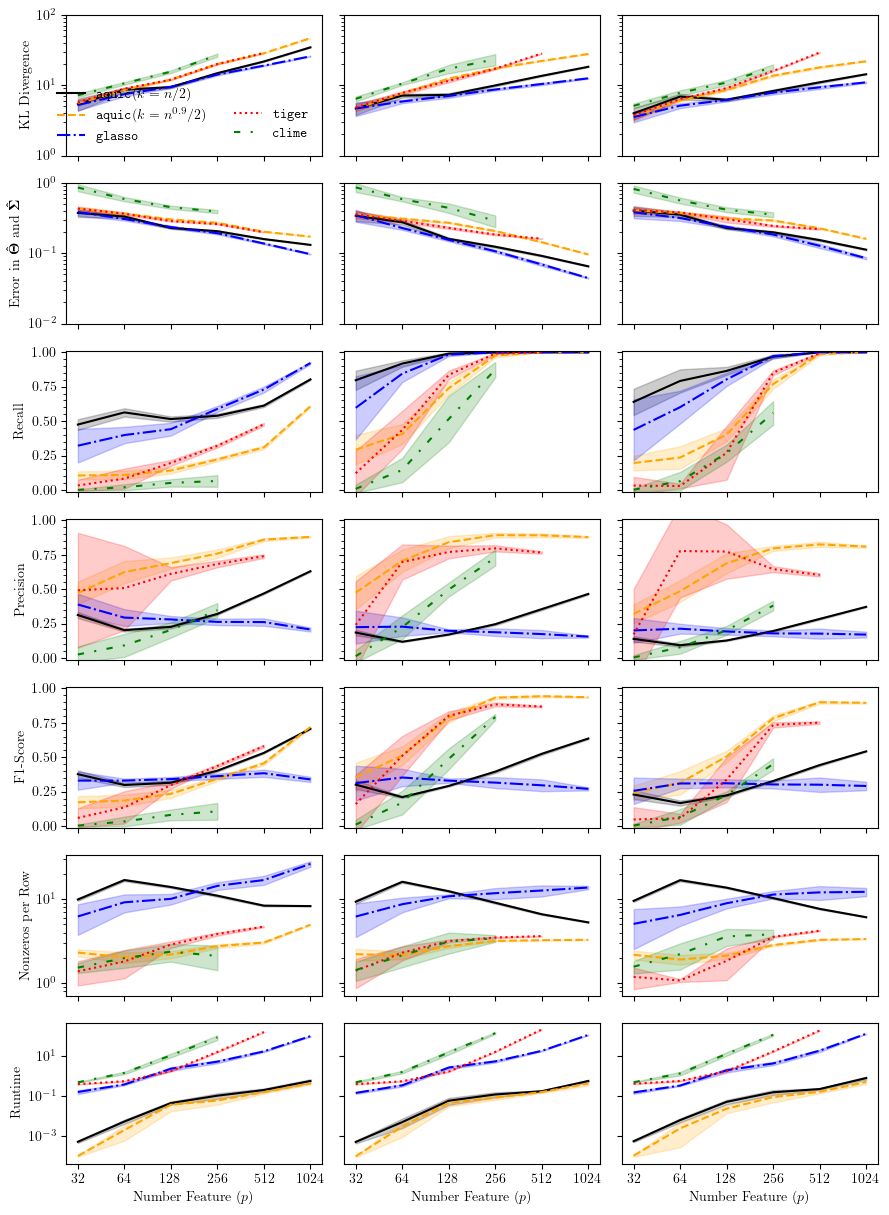

In [7]:
file_name = "data_err2"
[x_line, dataframe] = pd.read_pickle(file_name + ".pkl") 

fig, axs = make_plot(7, 3, s=[1, .7], sharex=True, sharey='row')

std_band = 1

i = 0
# KL Divergence
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].kl.mean(0)
    v = dataframe[data_type]['aquic1'].kl.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}(k=n/2)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].kl.mean(0)
    v = dataframe[data_type]['aquic2'].kl.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}(k=n^{0.9}/2)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].kl.mean(0)
    v = dataframe[data_type]['glasso'].kl.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    axs[i, inx].semilogy([], [],linestyle=None,label=r" ",linewidth=0)

    # tiger
    m = dataframe[data_type]['tiger'].kl.mean(0)
    v = dataframe[data_type]['tiger'].kl.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].kl.mean(0)
    v = dataframe[data_type]['clime'].kl.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([1, 1e2])
axs[i, 0].set_ylabel(r'KL Divergence')
axs[i, 0].minorticks_on()

i = i + 1
# Error in C and iC
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = (dataframe[data_type]['aquic1'].err_iC.mean(0) + dataframe[data_type]['aquic1'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['aquic1'].err_iC.std(0) + dataframe[data_type]['aquic1'].err_C.std(0)) / 2) * std_band
    axs[i, inx].semilogy(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = (dataframe[data_type]['aquic2'].err_iC.mean(0) + dataframe[data_type]['aquic2'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['aquic2'].err_iC.std(0) + dataframe[data_type]['aquic2'].err_C.std(0)) / 2) * std_band
    axs[i, inx].semilogy(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = (dataframe[data_type]['glasso'].err_iC.mean(0) + dataframe[data_type]['glasso'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['glasso'].err_iC.std(0) + dataframe[data_type]['glasso'].err_C.std(0)) / 2) * std_band
    axs[i, inx].semilogy(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = (dataframe[data_type]['tiger'].err_iC.mean(0) + dataframe[data_type]['tiger'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['tiger'].err_iC.std(0) + dataframe[data_type]['tiger'].err_C.std(0)) / 2) * std_band  
    axs[i, inx].semilogy(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = (dataframe[data_type]['clime'].err_iC.mean(0) + dataframe[data_type]['clime'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['clime'].err_iC.std(0) + dataframe[data_type]['clime'].err_C.std(0)) / 2) * std_band
    axs[i, inx].semilogy(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([1e-2, 1])
axs[i, 0].set_ylabel(r"Error in $\mathbf{\hat{\Theta}}$ and $\mathbf{\hat{\Sigma}}$")
axs[i, 0].minorticks_on()

i = i + 1
# Recall
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].recall.mean(0)
    v = dataframe[data_type]['aquic1'].recall.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].recall.mean(0)
    v = dataframe[data_type]['aquic2'].recall.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].recall.mean(0)
    v = dataframe[data_type]['glasso'].recall.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].recall.mean(0)
    v = dataframe[data_type]['tiger'].recall.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].recall.mean(0)
    v = dataframe[data_type]['clime'].recall.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'Recall')
axs[i, 0].minorticks_on()

i = i + 1
# Precision
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].precision.mean(0)
    v = dataframe[data_type]['aquic1'].precision.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].precision.mean(0)
    v = dataframe[data_type]['aquic2'].precision.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].precision.mean(0)
    v = dataframe[data_type]['glasso'].precision.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].precision.mean(0)
    v = dataframe[data_type]['tiger'].precision.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].precision.mean(0)
    v = dataframe[data_type]['clime'].precision.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'Precision')
axs[i, 0].minorticks_on()

i = i + 1
# F1 Score
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].f1.mean(0)
    v = dataframe[data_type]['aquic1'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].f1.mean(0)
    v = dataframe[data_type]['aquic2'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].f1.mean(0)
    v = dataframe[data_type]['glasso'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].f1.mean(0)
    v = dataframe[data_type]['tiger'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].f1.mean(0)
    v = dataframe[data_type]['clime'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'F1-Score')
axs[i, 0].minorticks_on()

i = i + 1
# Nonzeros per Row
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].nnz.mean(0)
    v = dataframe[data_type]['aquic1'].nnz.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].nnz.mean(0)
    v = dataframe[data_type]['aquic2'].nnz.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].nnz.mean(0)
    v = dataframe[data_type]['glasso'].nnz.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].nnz.mean(0)
    v = dataframe[data_type]['tiger'].nnz.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].nnz.mean(0)
    v = dataframe[data_type]['clime'].nnz.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylabel(r'Nonzeros per Row')
axs[i, 0].minorticks_on()

i = i + 1
# Runtime
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].runtime.mean(0)
    v = dataframe[data_type]['aquic1'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].runtime.mean(0)
    v = dataframe[data_type]['aquic2'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].runtime.mean(0)
    v = dataframe[data_type]['glasso'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].runtime.mean(0)
    v = dataframe[data_type]['tiger'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].runtime.mean(0)
    v = dataframe[data_type]['clime'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")
    
    axs[i, inx].set_xticks(x_line)
    axs[i, inx].set_xlabel(r'Number Feature ($p$)')

# axs[i, 0].set_ylim([0, 1])
axs[i, 0].set_ylabel(r'Runtime')
axs[i, 0].minorticks_on()
axs[i, 0].set_xscale('log', base=2)

axs[i, 0].set_xticks(x_line)
axs[i, 0].set_xticklabels([str(int(val)) for val in x_line])

axs[0, 0].legend(loc='lower right', frameon=False, fontsize=10, ncol=2)

fig.savefig("fig_4.png", dpi=300, bbox_inches='tight')

fig_size_pixels = fig.get_size_inches() 
print("Figure size (width x height in pixels):", fig_size_pixels,fig_size_pixels[1]/fig_size_pixels[0])